<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/spatial/02_uzamsal_kumeleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uzamsal olarak değişken genler

Önceki rehberde kümeler doku üzerinde anatomik bölgeler oluşturdu. Bu defterde soruyu gen düzeyine indiriyoruz: bir genin ifadesi doku üzerinde rastgele mi dağılıyor, yoksa belirli bölgelerde mi toplanıyor? Ölçüt olarak uzamsal otokorelasyonu, yani Moran's I istatistiğini kullanacağız.

In [1]:
%pip install -q scanpy squidpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10

## 1. Veri ve hazırlık

`squidpy`, scanpy'nin uzamsal analiz için geliştirilmiş kardeş kütüphanesidir; komşuluk grafiği, otokorelasyon ve doku içi komşuluk analizleri buradan gelir. Hazırlık 3.2'nin ilk adımlarıyla aynı: normalize et, log al, değişken genleri bayrakla, `raw`'a tam matrisi sakla. Bu defterde daraltma yapmıyoruz; ölçümü bayraklı genler üzerinde koşacağız ama matrisin tamamı elimizde kalsın.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

urllib.request.urlretrieve('https://zenodo.org/records/22758390/files/spatial_ders.h5ad?download=1', 'spatial_ders.h5ad')
v = sc.read_h5ad('spatial_ders.h5ad')

v.layers['sayim'] = v.X.copy()
sc.pp.normalize_total(v, target_sum=1e4)
sc.pp.log1p(v)
sc.pp.highly_variable_genes(v, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
v.raw = v
degisken = list(v.var_names[v.var.highly_variable])
print('spot × gen:', v.shape, '| test edilecek gen:', len(degisken))

spot × gen: (2702, 19653) | test edilecek gen: 2614


## 2. Uzamsal komşuluk grafiği

`sq.gr.spatial_neighbors(v)` her spotu doku üzerindeki komşularına bağlar. Bu grafik, 2.3'teki `sc.pp.neighbors`'dan tamamen farklıdır: orada komşuluk PCA uzayında, yani gen ifadesi benzerliğine göre kuruluyordu; burada komşuluk `obsm['spatial']` koordinatlarına, yani fiziksel yakınlığa göre kurulur. Visium'un altıgen düzeninde her iç spotun altı komşusu vardır ve fonksiyon bu düzeni otomatik tanır.

Sonuç `obsp` içine iki matris olarak yazılır: `spatial_connectivities` (kim kimin komşusu) ve `spatial_distances`.

In [3]:
sq.gr.spatial_neighbors(v)
print('komşuluk matrisi:', v.obsp['spatial_connectivities'].shape)
print('spot başına ortalama komşu: %.1f' % (v.obsp['spatial_connectivities'].nnz / v.n_obs))

INFO     Creating graph using `None` transform and `1` libraries.                                                  
komşuluk matrisi: (2702, 2702)
spot başına ortalama komşu: 5.8


## 3. Moran's I

Moran's I, bir değerin uzamsal olarak kümelenip kümelenmediğini ölçer. Mantığı şudur: her spotun değeri, komşularının değerleriyle karşılaştırılır. Yüksek değerli spotların komşuları da yüksekse ve düşüklerin komşuları düşükse istatistik 1'e yaklaşır; değerler komşuluktan bağımsız dağılmışsa 0 civarında kalır; komşular sistematik olarak zıtsa negatife iner.

`sq.gr.spatial_autocorr(v, mode='moran', genes=..., n_perms=None)` bunu her gen için hesaplar. `mode='moran'` istatistiği seçer; `genes` hangi genlerin test edileceğini belirler; `n_perms=None` p değerlerinin permütasyon yerine normal yaklaşımla hesaplanmasını sağlar — permütasyon daha titizdir ama binlerce gen için dakikalar sürer, normal yaklaşım saniyeler.

Sonuç `v.uns['moranI']` tablosuna I değerine göre sıralı yazılır. Sütunlar: `I` istatistiğin kendisi, `pval_norm` ham p değeri, `pval_norm_fdr_bh` çoklu test düzeltmesinden geçmiş hali — birinci serideki Benjamini-Hochberg düzeltmesinin aynısı, binlerce gen test edildiği için zorunlu.

In [4]:
sq.gr.spatial_autocorr(v, mode='moran', genes=degisken, n_perms=None, n_jobs=2)

m = v.uns['moranI']
print(m[['I', 'pval_norm', 'pval_norm_fdr_bh']].head(15).to_string())
print('\nFDR<0.05 olan gen:', int((m.pval_norm_fdr_bh < 0.05).sum()), '/', len(m))
print('I<0.1 olan gen:', int((m.I < 0.1).sum()))

                I  pval_norm  pval_norm_fdr_bh
Nrgn     0.889357        0.0               0.0
Camk2n1  0.870434        0.0               0.0
Prkcd    0.867447        0.0               0.0
Slc17a7  0.864086        0.0               0.0
Pmch     0.849476        0.0               0.0
Tcf7l2   0.833402        0.0               0.0
Mobp     0.827054        0.0               0.0
Agrp     0.812906        0.0               0.0
Cck      0.808917        0.0               0.0
Ddn      0.801109        0.0               0.0
Tnnt1    0.800699        0.0               0.0
Nptxr    0.795828        0.0               0.0
Sparc    0.792702        0.0               0.0
Camk2a   0.774085        0.0               0.0
Olfm1    0.771833        0.0               0.0

FDR<0.05 olan gen: 2395 / 2614
I<0.1 olan gen: 886


## 4. Tepeyi ve dibi doku üzerinde görmek

İstatistiğin ne ölçtüğünü anlamanın en iyi yolu, uçları çizmek. Aşağıda en yüksek I değerine sahip dört gen ile listenin dibinden bir gen doku üzerinde çizilir. Tepedekilerde ifade belirli bölgelerde toplanmış olmalı; dipteki gende doku boyunca rastgele bir serpinti görmelisiniz.

tepe: ['Nrgn', 'Camk2n1', 'Prkcd', 'Slc17a7'] | dip: Gm49741


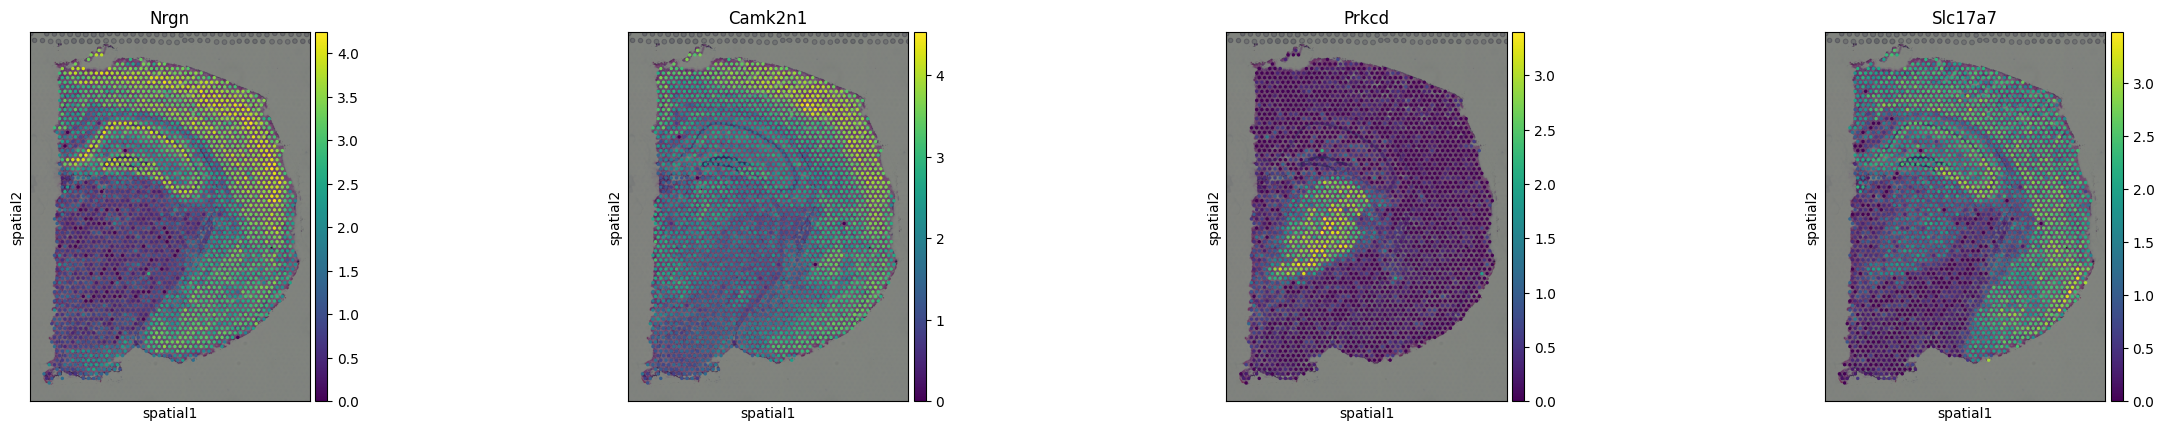

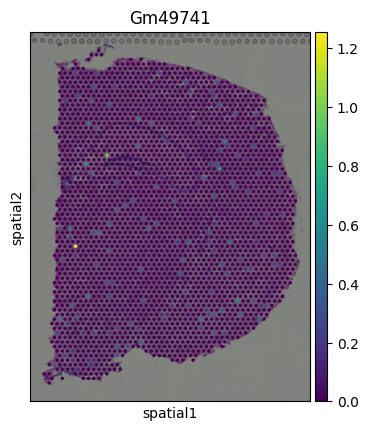

In [5]:
tepe = list(m.index[:4])
dip = m.index[-1]
print('tepe:', tepe, '| dip:', dip)
sc.pl.spatial(v, color=tepe)
sc.pl.spatial(v, color=[dip])

## 5. İki listeyi karşılaştırmak

Değişken gen seçimi (`highly_variable_genes`) ile uzamsal değişkenlik iki farklı sorudur. İlki "bu gen spotlar arasında değişiyor mu" diye sorar ve koordinatları hiç kullanmaz; ikincisi "bu değişim doku üzerinde desenli mi" diye sorar. Bir gen çok değişken olup uzamsal deseni olmayabilir. Aşağıdaki hücre bu iki listenin ne kadar örtüştüğünü sayar.

In [6]:
esik = m[m.pval_norm_fdr_bh < 0.05]
print('Değişken gen sayısı:', len(degisken))
print('Bunların uzamsal olarak anlamlı olanı:', len(esik))
print('Uzamsal deseni zayıf olan (I<0.1):', int((m.I < 0.1).sum()))

Değişken gen sayısı: 2614
Bunların uzamsal olarak anlamlı olanı: 2395
Uzamsal deseni zayıf olan (I<0.1): 886


## Kendin dene

Üç görev. Birincisi: tablonun ilk üç genini ve I değerlerini not edin; bu genleri 3.2'deki küme haritasıyla karşılaştırıp hangi anatomik bölgeye denk geldiklerini yazın. İkincisi: en yüksek ve en düşük I değerli genlerin doku görüntülerini karşılaştırıp tek cümleyle yazın — Moran's I tam olarak neyi ölçüyor? Üçüncüsü: 886 civarında gen hem değişken bayrağı almış hem de uzamsal deseni zayıf çıkıyor; tek cümleyle açıklayın, bu nasıl mümkün ve bu genler biyolojik olarak ne tür değişkenliği temsil ediyor olabilir?